# Orbital Debris Database: Exploring the Landscape

**Database:** orbital_debris.db (SQLite)  
**Docs:** See quick reports in notebook 04 and data dictionary in `docs/schema` for full schema and field definitions.

**Goal:** Surface patterns, outliers, and new questions in the orbital debris database to guide deeper analysis and visualization.

### Why this notebook?
This notebook builds on the cleaned, joined database. Instead of repeating full audits, it focuses on targeted exploration, query prototyping, and visual storytelling to support research questions and analysis.

### What we do here
1. **Prototype questions:** Use SQL and pandas to dig into specific trends, outliers, or hypotheses.
2. **Visualize:** Create quick charts to spot patterns and inform next steps.
3. **Document findings:** Save useful queries, charts, and notes for future reference.

*For table structure, nulls, and sample data, see the end of notebook 04 and the data dictionary.*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3 as sql
import utility as utils
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown

plt.rcParams.update({
    "grid.alpha": 0.3,
    "axes.facecolor": "#333333",
    "figure.facecolor": "#333333",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.facecolor": "#333333",
    "legend.edgecolor": "white"
})
 
orbital_debris_conn = sql.connect('../data/clean/orbital_debris.db')
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

**Note:** Full quick reports for all database tables are generated at the end of notebook 04 (`04_orbital_debris_synthesis.ipynb`). See that notebook for detailed table structure, nulls, and sample data. For field definitions and schema details, refer to the data dictionary in `docs/schema`. This notebook focuses on exploration and analysis.

### Launch Year Trends: Decoupling Point in Orbital Growth
 
**Intent:** Identify when orbital object growth shifted from linear to exponential by visualizing launches per year.
 
**Method:**
- Query the satellites table for launch years.
- Count and plot the number of objects launched per year.
- Visually inspect for inflection points or rapid growth phases.

In [2]:
# Query: Launches per year
launches_per_year_query = """
SELECT
    satellites.norad_id,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_launches_per_year = pd.read_sql_query(launches_per_year_query, orbital_debris_conn)

# Convert to datetime and extract year
df_launches_per_year['launch_year'] = pd.to_datetime(df_launches_per_year['launch_date'], errors='coerce').dt.year

df_launches_per_year.to_parquet('../data/clean/results/launches_per_year_exp.parquet', index=False)

In [3]:
# Validation: Check for nulls, unique years, and overall data integrity
print('Row count:', len(df_launches_per_year))
display(df_launches_per_year.head())
display(df_launches_per_year.tail())

print('Unique years:', df_launches_per_year["launch_year"].nunique())
print('Year range:', df_launches_per_year["launch_year"].min(), '-', df_launches_per_year["launch_year"].max())

print('Nulls per column:')
display(df_launches_per_year.isnull().sum())

print('Sample years:', df_launches_per_year["launch_year"].unique()[:10])

Row count: 33348


,norad_id,launch_date,launch_year
0,5,1958-03-17,1958
1,16,1958-03-17,1958
2,1576,1958-03-17,1958
3,112,1959-01-02,1959
4,11,1959-02-17,1959


,norad_id,launch_date,launch_year
33343,68377,2026-03-25,2026
33344,68378,2026-03-25,2026
33345,68379,2026-03-25,2026
33346,68405,2026-03-27,2026
33347,68408,2026-03-28,2026


Unique years: 69
Year range: 1958 - 2026
Nulls per column:


norad_id       0
launch_date    0
launch_year    0
dtype: int64

Sample years: [1958 1959 1960 1961 1962 1963 1964 1965 1966 1967]


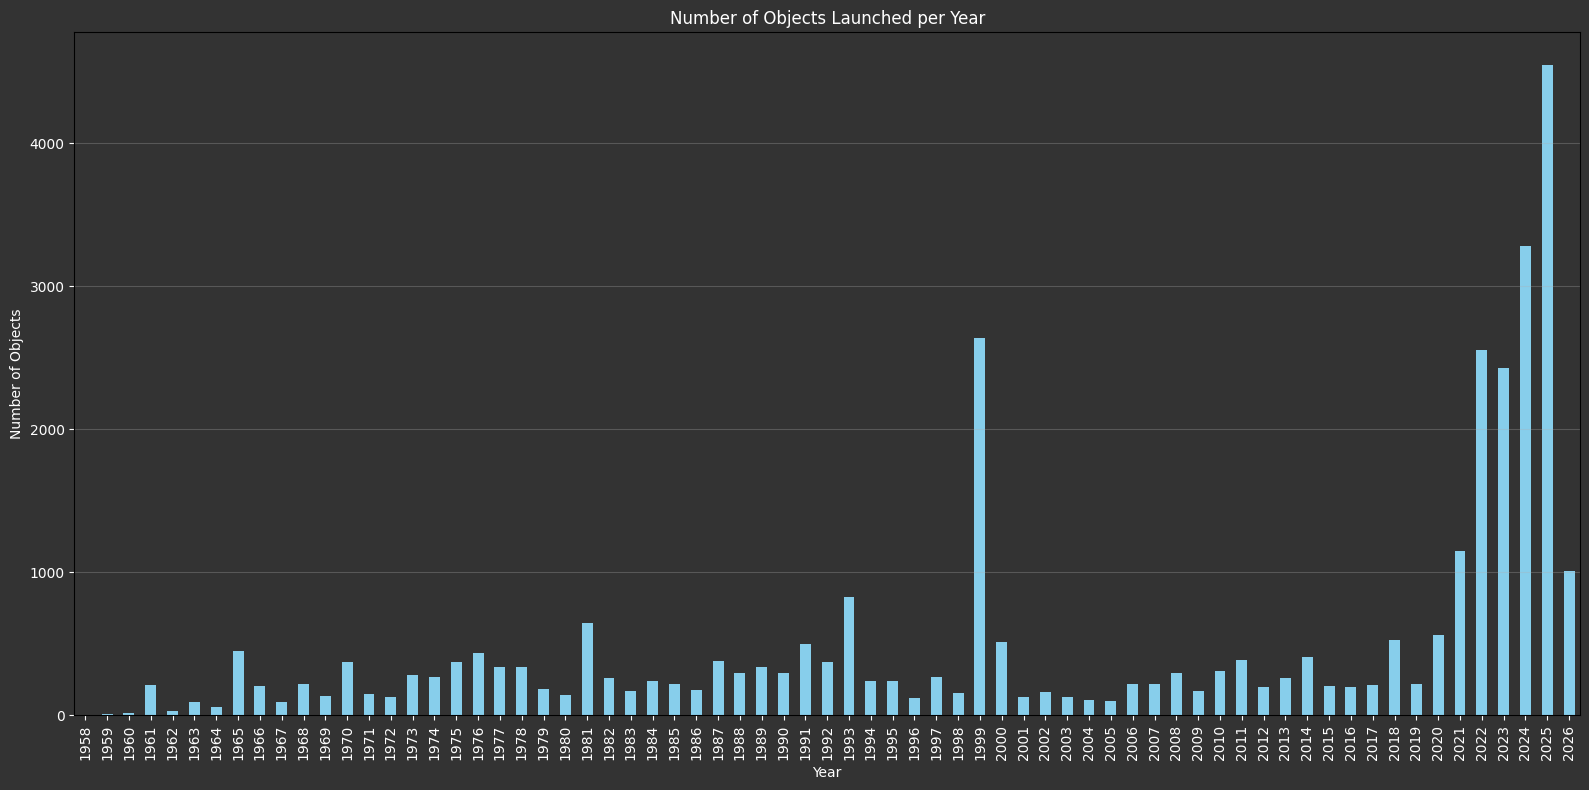

In [4]:
# Count the number of launches per year
launch_counts = df_launches_per_year['launch_year'].value_counts().sort_index()

plt.figure(figsize=(16,8))
launch_counts.plot(kind='bar', color='skyblue')

plt.title('Number of Objects Launched per Year')
plt.xlabel('Year')
plt.ylabel('Number of Objects')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/launches_per_year_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/launches_per_year_exp.png', bbox_inches='tight', dpi=300)
plt.show()

### Debris Growth Over Time: Annual Debris Object Counts

**Intent:** Visualize the trend of debris objects in orbit by year to identify growth patterns and inflection points.

**Method:**
- Query the debris table (or filter satellites table for debris type) for object type = 'DEBRIS'.
- Extract/convert launch or identification year.
- Count and plot the number of debris objects per year.
- Validate row/column counts and check for missing years or anomalies.

In [5]:
# Query: Debris objects per year
debris_query = """
SELECT
    satellites.norad_id,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.object_type = 'DEBRIS' AND launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_debris_per_year = pd.read_sql_query(debris_query, orbital_debris_conn)

# Convert to datetime and extract year
df_debris_per_year['debris_year'] = pd.to_datetime(df_debris_per_year['launch_date'], errors='coerce').dt.year

# Save the query result to a parquet file for future use.
df_debris_per_year.to_parquet('../data/clean/results/debris_per_year_exp.parquet', index=False)

In [6]:
# Validation: Debris Growth Data Integrity
print('Row count:', len(df_debris_per_year))
display(df_debris_per_year.head())
display(df_debris_per_year.tail())

print('Unique years:', df_debris_per_year["debris_year"].nunique())
print('Year range:', df_debris_per_year["debris_year"].min(), '-', df_debris_per_year["debris_year"].max())

print('Nulls per column:')
display(df_debris_per_year.isnull().sum())

print('Sample years:', df_debris_per_year["debris_year"].unique()[:10])

Row count: 12556


,norad_id,launch_date,debris_year
0,1576,1958-03-17,1958
1,61446,1959-02-17,1959
2,115,1960-04-01,1960
3,51,1960-08-12,1960
4,52,1960-08-12,1960


,norad_id,launch_date,debris_year
12551,67692,2026-02-07,2026
12552,67718,2026-02-07,2026
12553,67719,2026-02-07,2026
12554,67720,2026-02-07,2026
12555,67763,2026-02-12,2026


Unique years: 69
Year range: 1958 - 2026
Nulls per column:


norad_id       0
launch_date    0
debris_year    0
dtype: int64

Sample years: [1958 1959 1960 1961 1962 1963 1964 1965 1966 1967]


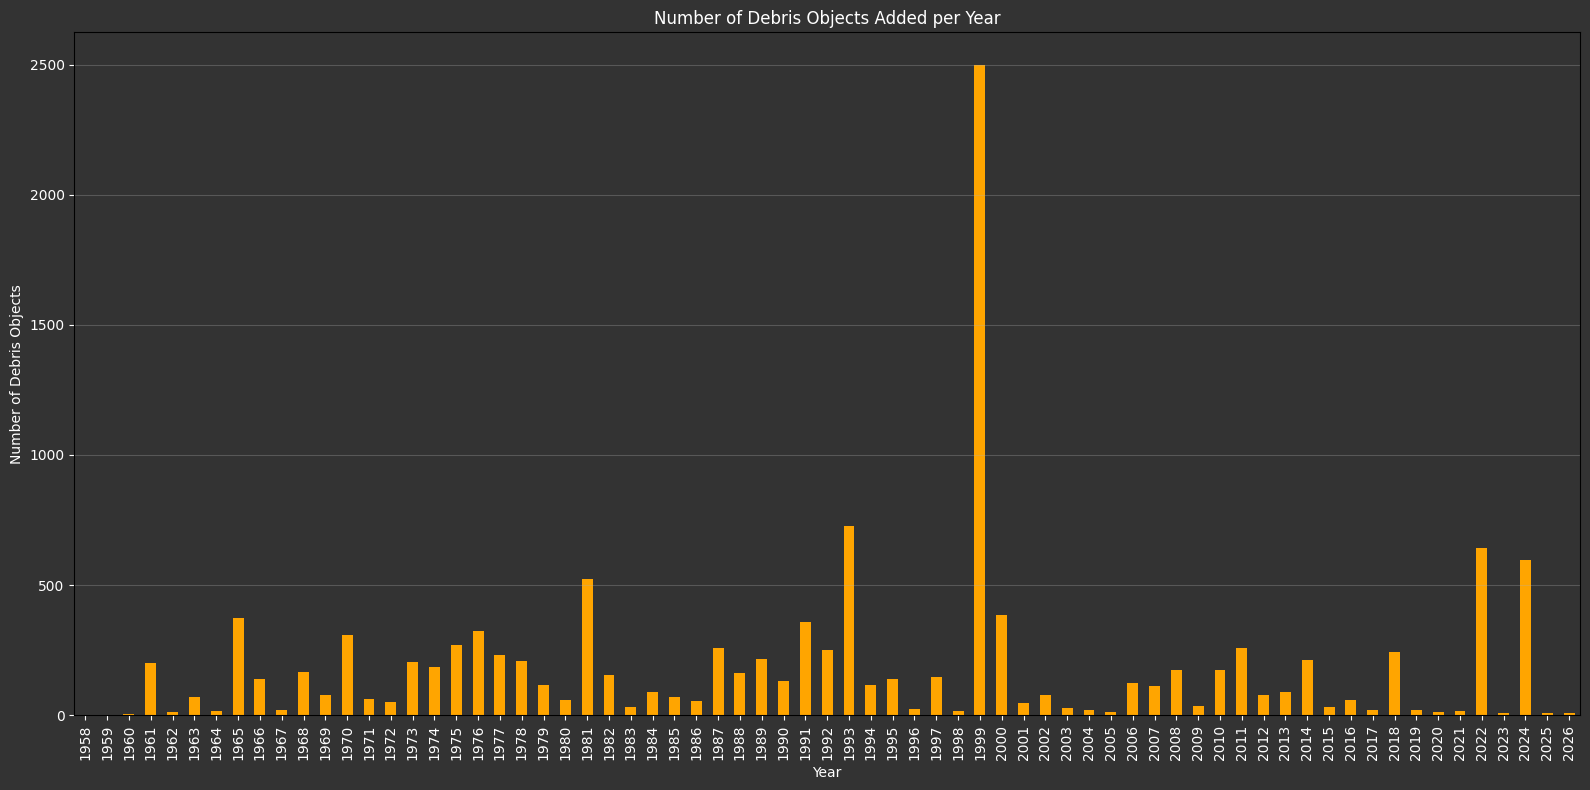

In [7]:
# Count debris objects per year
debris_counts = df_debris_per_year['debris_year'].value_counts().sort_index()

plt.figure(figsize=(16,8))

debris_counts.plot(kind='bar', color='orange')

plt.title('Number of Debris Objects Added per Year')
plt.xlabel('Year')
plt.ylabel('Number of Debris Objects')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/debris_per_year_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/debris_per_year_exp.png', bbox_inches='tight', dpi=300)
plt.show()

### Object Type Distribution: How the Mix of Payloads, Rocket Bodies, and Debris Changes Over Time

**Intent:** Show how the proportions of payloads, rocket bodies, and debris have shifted over time, highlighting changes in the orbital environment.

**Method:**
- Query the satellites table (joined with launch_events) for object type and launch year.
- Group and count by year and object type.
- Visualize as a stacked bar or area chart to show the mix over time.
- Validate for missing years, nulls, and object type coverage.

In [8]:
# Query: Object type distribution by year
object_type_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_type_year = pd.read_sql_query(object_type_query, orbital_debris_conn)

# Convert to datetime and extract year
df_type_year['launch_year'] = pd.to_datetime(df_type_year['launch_date'], errors='coerce').dt.year

# Save the query result to a parquet file for future use.
df_type_year.to_parquet('../data/clean/results/object_type_year_exp.parquet', index=False)


In [9]:
# Validation: Object Type Distribution Data Integrity
print('Row count:', len(df_type_year))
display(df_type_year.head())

print('Unique years:', df_type_year["launch_year"].nunique())
print('Year range:', df_type_year["launch_year"].min(), '-', df_type_year["launch_year"].max())
print('Object types:', df_type_year["object_type"].unique())

print('Nulls per column:')
display(df_type_year.isnull().sum())

print('Sample years:', df_type_year["launch_year"].unique()[:10])

Row count: 33348


,norad_id,object_type,launch_date,launch_year
0,5,PAYLOAD,1958-03-17,1958
1,16,ROCKET BODY,1958-03-17,1958
2,1576,DEBRIS,1958-03-17,1958
3,112,PAYLOAD,1959-01-02,1959
4,11,PAYLOAD,1959-02-17,1959


Unique years: 69
Year range: 1958 - 2026
Object types: ['PAYLOAD' 'ROCKET BODY' 'DEBRIS' 'UNKNOWN']
Nulls per column:


norad_id       0
object_type    0
launch_date    0
launch_year    0
dtype: int64

Sample years: [1958 1959 1960 1961 1962 1963 1964 1965 1966 1967]


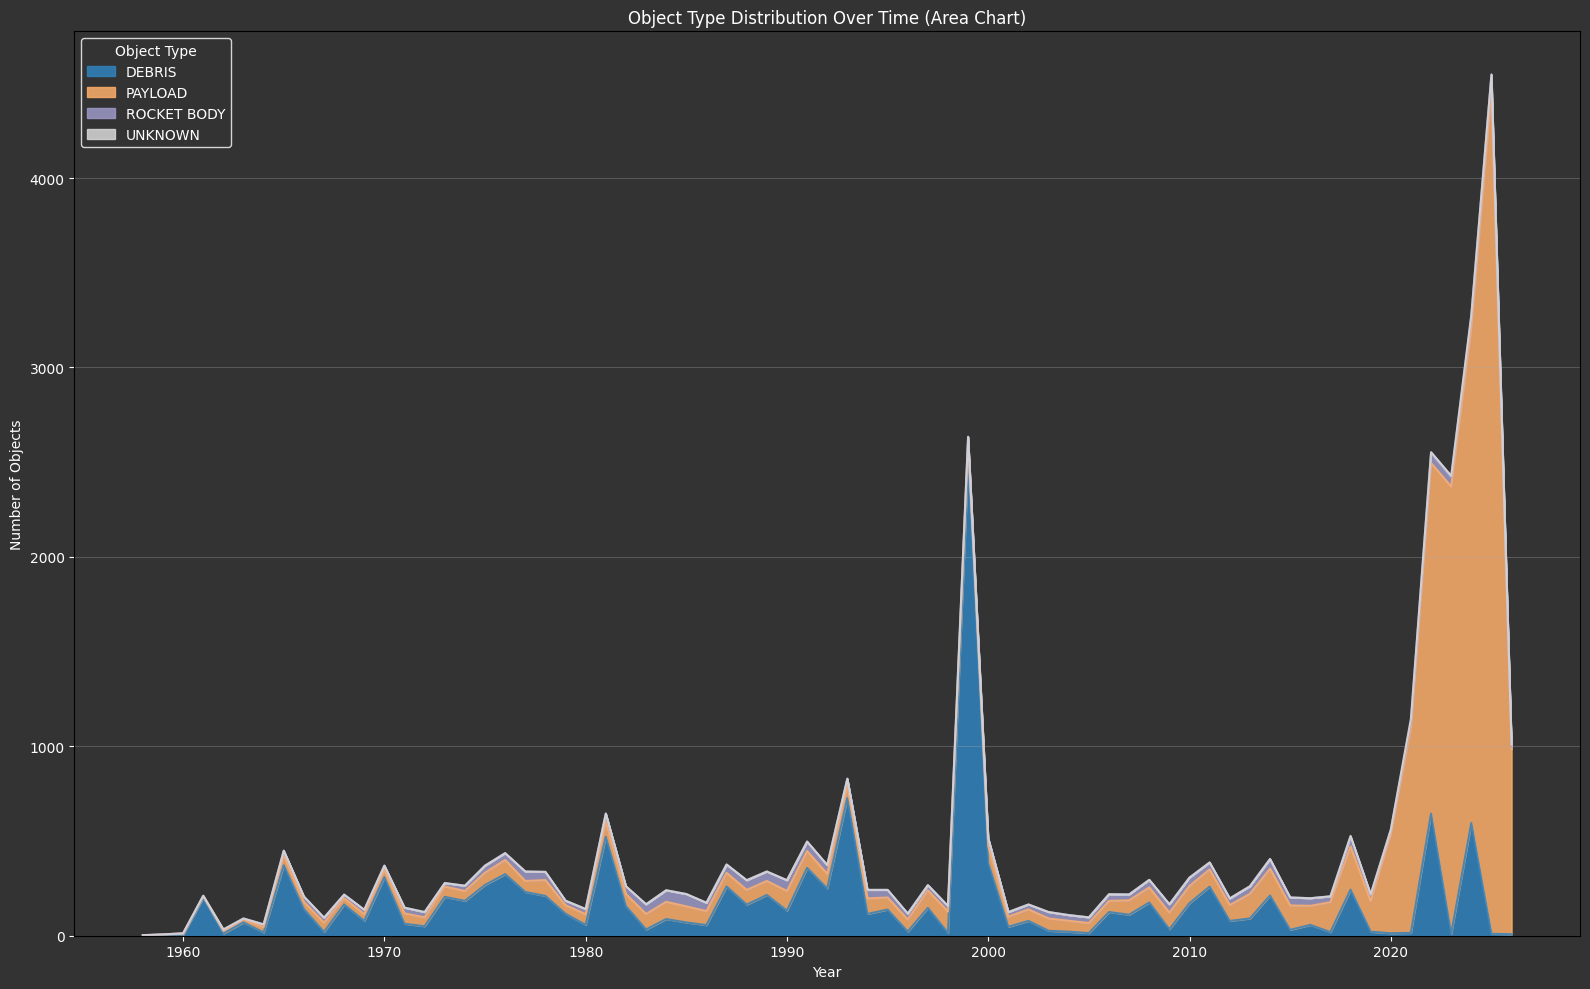

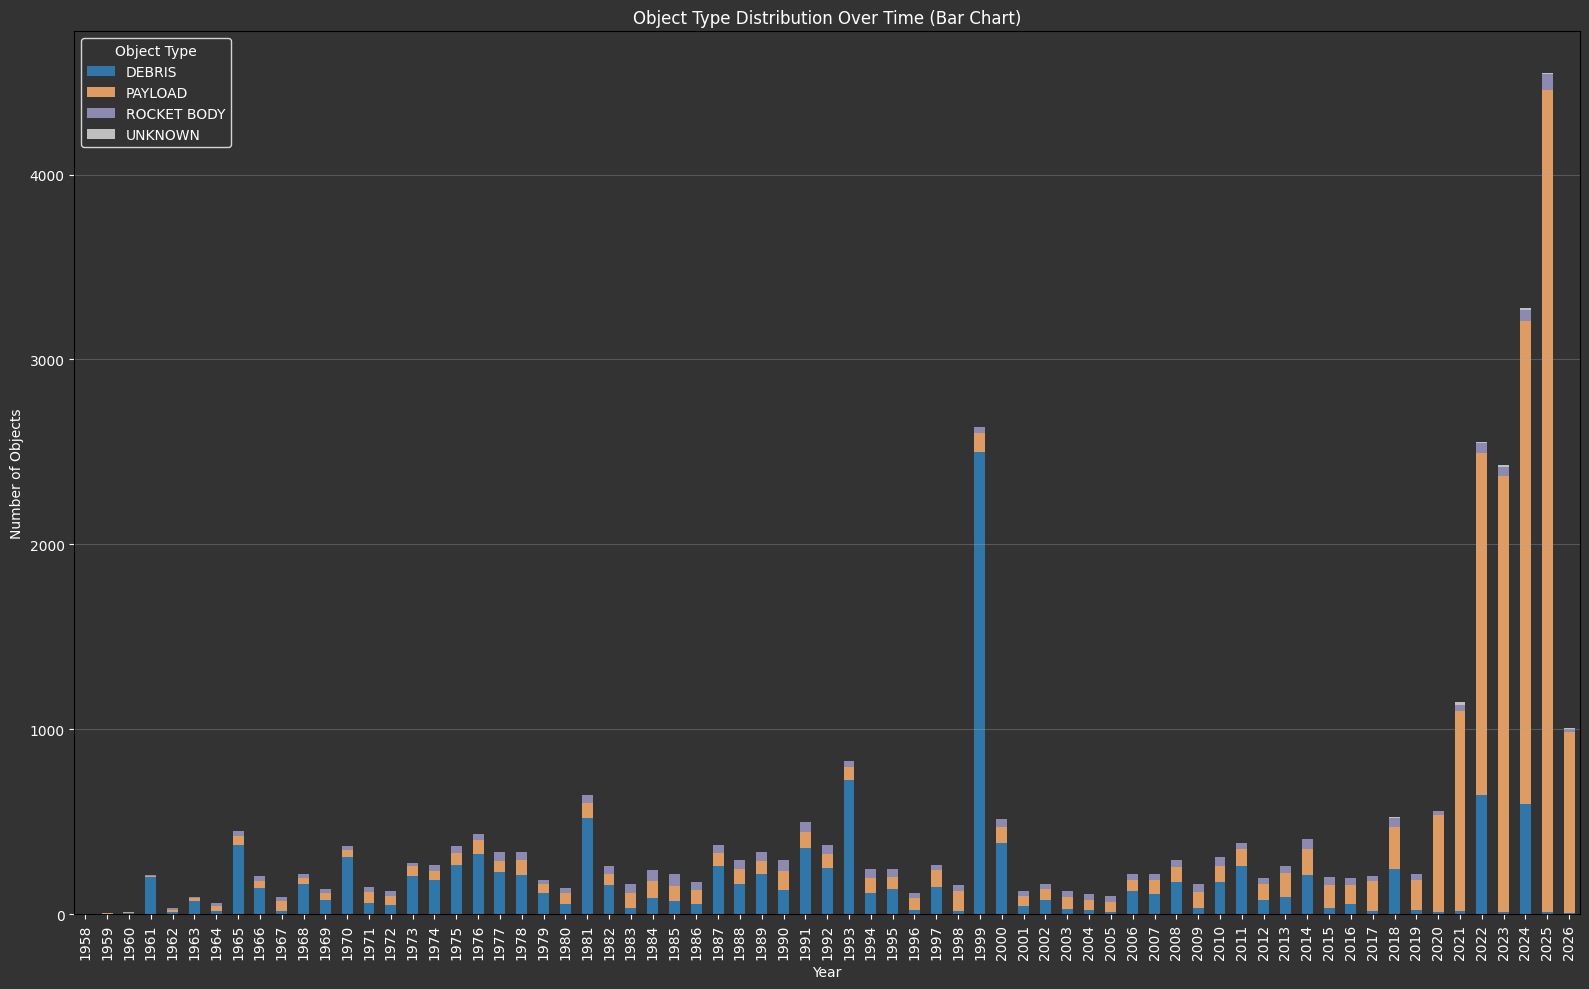

In [10]:
# Group by year and object type, count
type_counts = df_type_year.groupby(['launch_year', 'object_type']).size().unstack(fill_value=0)

# Plot: Stacked area chart
plt.figure(figsize=(16,10))
type_counts.plot.area(ax=plt.gca(), alpha=0.85, colormap='tab20c')

plt.title('Object Type Distribution Over Time (Area Chart)')
plt.xlabel('Year')
plt.ylabel('Number of Objects')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Object Type')

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/object_type_distribution_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/object_type_distribution_exp.png', bbox_inches='tight', dpi=300)
plt.show()

# vertical bar chart alternative

plt.figure(figsize=(16,10))
type_counts.plot(kind='bar', stacked=True, ax=plt.gca(), alpha=0.85, colormap='tab20c')

plt.title('Object Type Distribution Over Time (Bar Chart)')
plt.xlabel('Year')
plt.ylabel('Number of Objects')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Object Type')

plt.tight_layout()
plt.savefig('../charts/questions/exploratory/svg/object_type_distribution_bar_exp.svg', bbox_inches='tight')
plt.savefig('../charts/questions/exploratory/png/object_type_distribution_bar_exp.png', bbox_inches='tight', dpi=300)
plt.show()


### High-Risk Object Counts: Number and Share Above Thresholds

**Intent:** Quantify the number and proportion of objects considered high-risk based on velocity and/or kinetic energy.

**Method:**
- Define velocity and/or kinetic energy thresholds for high risk.
- Query the database for objects above these thresholds.
- Calculate counts and share of total population.
- Validate for nulls and edge cases.

In [11]:
velocity_threshold = 7800  # m/s
kinetic_energy_threshold = 1e10  # joules

# Query: High-risk objects by velocity or kinetic energy
# We will be adding a row called 'altitude_km' which ( apogee + perigee ) /  2, 
# using the mean of perigee and apogee to estimate an object’s “typical” or “representative” 
# orbital altitude is standard practice in both academic literature and NASA/ESA data analysis.

high_risk_query = f'''
SELECT
  satellites.norad_id,
  satellites.object_name,
  satellites.object_type,
  launch_events.launch_date,
  orbital_data.orbit_class,
  orbital_data.apogee_km,
  orbital_data.perigee_km,
  orbital_data.proxy_mass_kg,
  (orbital_data.apogee_km + orbital_data.perigee_km) / 2 AS altitude_km,
  risk_assessment.velocity_kms,
  risk_assessment.kinetic_joules
FROM satellites 
JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id 
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE risk_assessment.kinetic_joules IS NOT NULL;
'''

df_all_sats = pd.read_sql_query(high_risk_query, orbital_debris_conn)
df_all_sats['launch_year'] = pd.to_datetime(df_all_sats['launch_date'], errors='coerce').dt.year
df_all_sats['risk_category'] = df_all_sats.apply(utils.classify_risk_category, axis=1)

df_high_risk = df_all_sats[
  (df_all_sats['risk_category'] == 'Extremely High Risk')
].copy()

# Save the query result to a parquet file for future use.
df_high_risk.to_parquet('../data/clean/results/high_risk_sats_exp.parquet', index=False)

In [12]:
# Count and share
total_objects = pd.read_sql_query('SELECT COUNT(*) as n FROM satellites;', orbital_debris_conn)['n'][0]
high_risk_count = len(df_high_risk)
high_risk_share = high_risk_count / total_objects if total_objects else float('nan')

print(f'Total objects with risk data: {len(df_all_sats)}')
display(df_all_sats.head())

print(f'High-risk objects: {high_risk_count} of {total_objects} ({high_risk_share:.2%})')
display(df_high_risk.head())

# Validation
print('Nulls per column:')
display(df_high_risk.isnull().sum())

Total objects with risk data: 33348


,norad_id,object_name,object_type,launch_date,orbit_class,apogee_km,perigee_km,proxy_mass_kg,altitude_km,velocity_kms,kinetic_joules,launch_year,risk_category
0,5,VANGUARD 1,PAYLOAD,1958-03-17,MEO,3818.0,654.0,355.0,2236.0,6.802590,8.213853e+09,1958,High Risk
1,11,VANGUARD 2,PAYLOAD,1959-02-17,LEO,2896.0,554.0,355.0,1725.0,7.013761,8.731729e+09,1959,High Risk
2,12,VANGUARD R/B,ROCKET BODY,1959-02-17,LEO,3286.0,554.0,2000.0,1920.0,6.930921,4.803766e+10,1959,Extremely High Risk
3,16,VANGUARD R/B,ROCKET BODY,1958-03-17,MEO,4213.0,654.0,2000.0,2433.5,6.725699,4.523503e+10,1958,Extremely High Risk
4,20,VANGUARD 3,PAYLOAD,1959-09-18,LEO,3205.0,508.0,355.0,1856.5,6.957475,8.592146e+09,1959,High Risk


High-risk objects: 12736 of 33348 (38.19%)


,norad_id,object_name,object_type,launch_date,orbit_class,apogee_km,perigee_km,proxy_mass_kg,altitude_km,velocity_kms,kinetic_joules,launch_year,risk_category
2,12,VANGUARD R/B,ROCKET BODY,1959-02-17,LEO,3286.0,554.0,2000.0,1920.0,6.930921,4.803766e+10,1959,Extremely High Risk
3,16,VANGUARD R/B,ROCKET BODY,1958-03-17,MEO,4213.0,654.0,2000.0,2433.5,6.725699,4.523503e+10,1958,Extremely High Risk
5,22,EXPLORER 7,PAYLOAD,1959-10-13,LEO,539.0,429.0,355.0,484.0,7.621379,1.031016e+10,1959,Extremely High Risk
6,27,PIONEER 5,PAYLOAD,1960-03-11,UNKNOWN,476.0,413.0,355.0,444.5,7.626506,1.032404e+10,1960,Extremely High Risk
7,29,TIROS 1,PAYLOAD,1960-04-01,LEO,650.0,618.0,355.0,634.0,7.539641,1.009020e+10,1960,Extremely High Risk


Nulls per column:


norad_id          0
object_name       0
object_type       0
launch_date       0
orbit_class       0
apogee_km         0
perigee_km        0
proxy_mass_kg     0
altitude_km       0
velocity_kms      0
kinetic_joules    0
launch_year       0
risk_category     0
dtype: int64

### Mass Distribution: High-Risk Objects (if available)

**Intent:** Examine the mass distribution of high-risk objects to identify heavy outliers or trends.

**Method:**
- If mass data is available, plot histogram or boxplot for high-risk objects.
- Validate for nulls and extreme values.

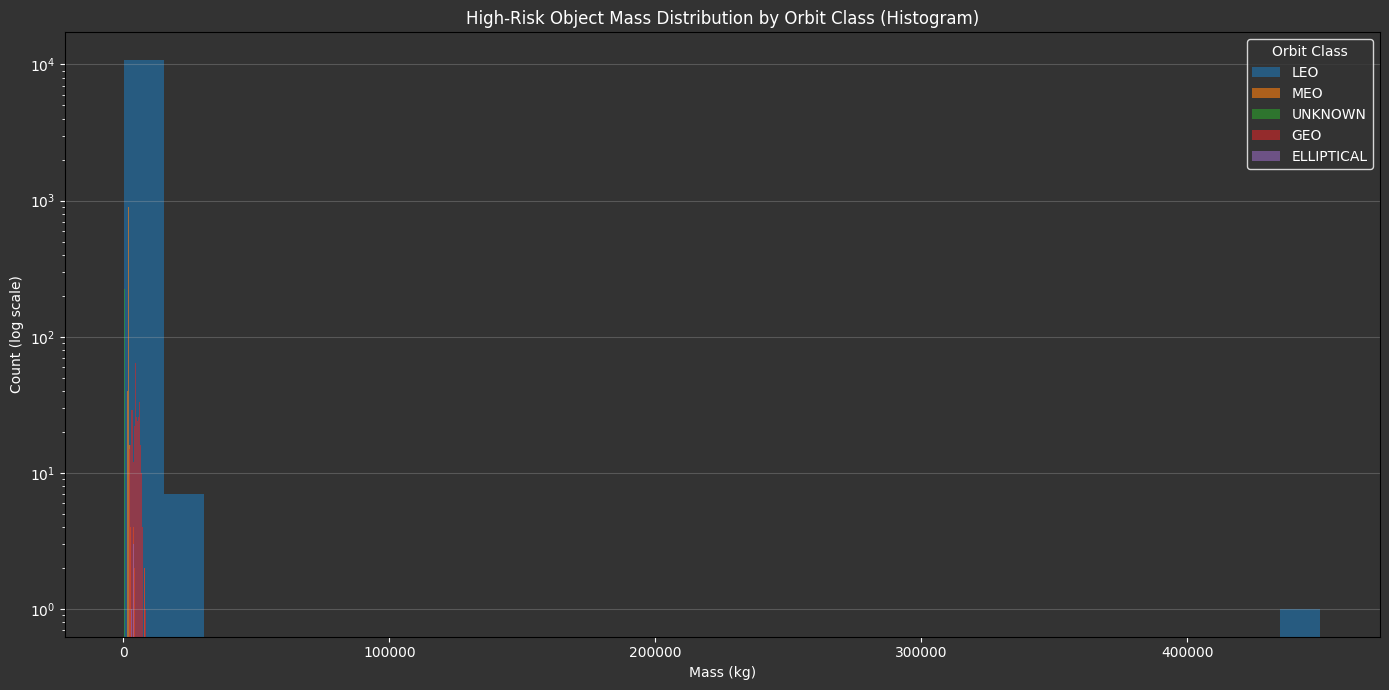

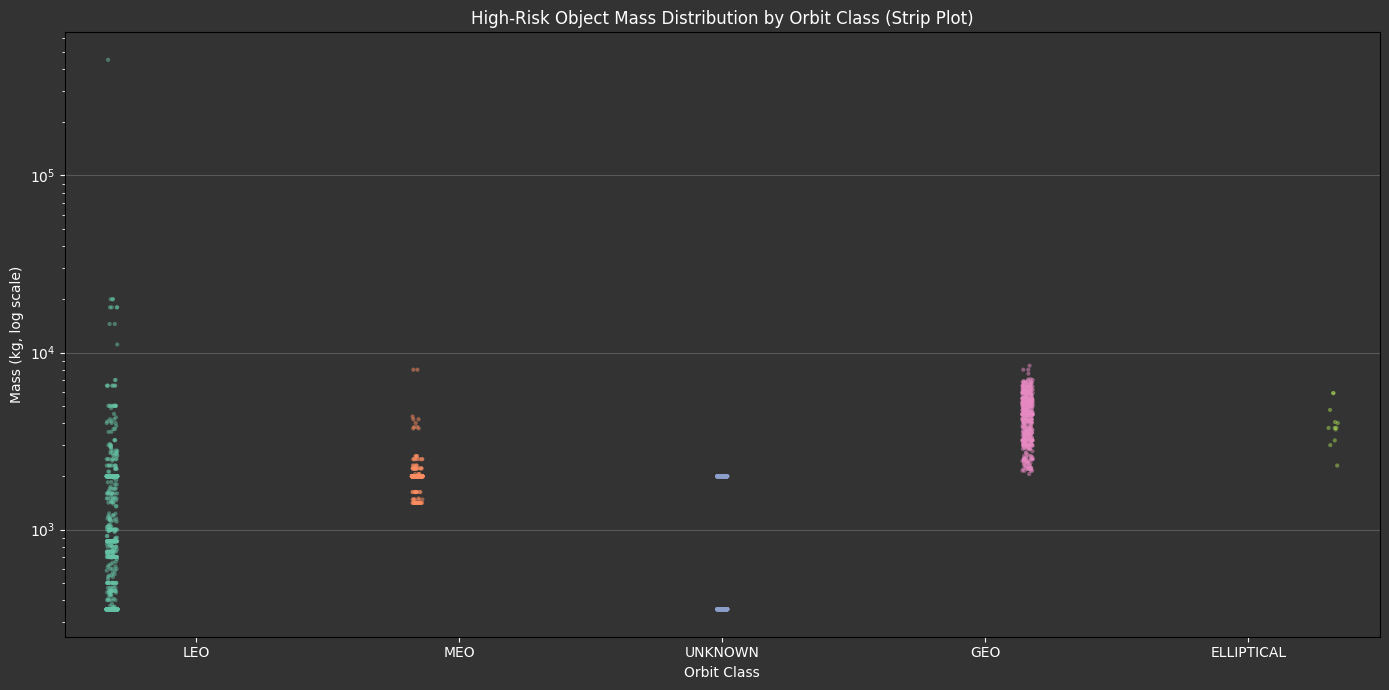

Objects with nonzero mass and orbit class: 12736


In [13]:
# Mass distribution for high-risk objects: histogram and strip plot by orbit_class
if 'proxy_mass_kg' in df_high_risk.columns and 'orbit_class' in df_high_risk.columns:
    mass_nonzero = df_high_risk[['proxy_mass_kg', 'orbit_class']].dropna()
    mass_nonzero = mass_nonzero[mass_nonzero['proxy_mass_kg'] > 0]
    
    # Histogram (all high-risk masses, colored by orbit_class)
    plt.figure(figsize=(14, 7))
    for oc in mass_nonzero['orbit_class'].unique():
        subset = mass_nonzero[mass_nonzero['orbit_class'] == oc]
        plt.hist(subset['proxy_mass_kg'], bins=30, alpha=0.6, label=oc)
    plt.yscale('log')
    plt.xlabel('Mass (kg)')
    plt.ylabel('Count (log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Histogram)')
    plt.legend(title='Orbit Class')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_mass_hist_by_orbit_class.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_mass_hist_by_orbit_class.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Strip plot (each point = object, grouped by orbit_class)
    plt.figure(figsize=(14, 7))
    sns.stripplot(x='orbit_class', y='proxy_mass_kg', data=mass_nonzero, hue='orbit_class', palette='Set2', size=3, dodge=True, alpha=0.5)
    plt.yscale('log')
    plt.xlabel('Orbit Class')
    plt.ylabel('Mass (kg, log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Strip Plot)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_mass_strip_by_orbit_class.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_mass_strip_by_orbit_class.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f'Objects with nonzero mass and orbit class: {len(mass_nonzero)}')
else:
    print('proxy_mass_kg or orbit_class column not found in high-risk data.')

### Orbit Class Breakdown: High-Risk Objects by Orbit Class

**Intent:** Show how high-risk objects are distributed across orbit classes (LEO, MEO, GEO, etc.).

**Method:**
- Use the high-risk subset from above.
- Group and count by orbit class.
- Visualize as a bar chart or pie chart.
- Validate for missing/unknown classes.

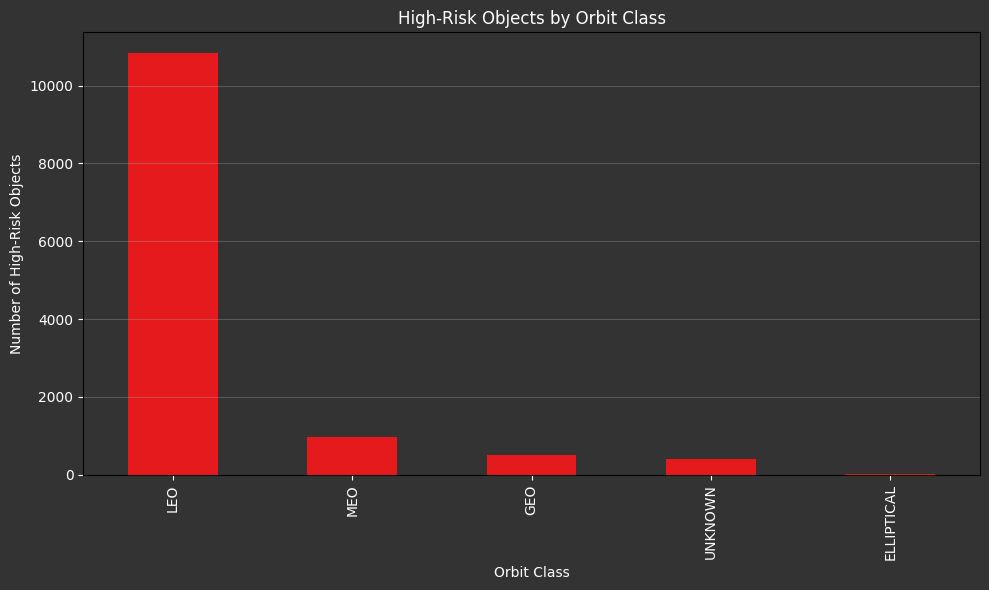

orbit_class
LEO           10829
MEO             978
GEO             508
UNKNOWN         409
ELLIPTICAL       12
Name: count, dtype: int64


In [14]:
# Group high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    orbit_counts.plot(kind='bar', colormap='Set1')
    
    plt.title('High-Risk Objects by Orbit Class')
    plt.xlabel('Orbit Class')
    plt.ylabel('Number of High-Risk Objects')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/hr_orbit_class_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/hr_orbit_class_exp.png', bbox_inches='tight', dpi=300)  
    plt.show()
    
    print(orbit_counts)
else:
    print('orbit_class column not found in high-risk data.')

### Altitude Band Analysis: 400–600 km LEO High-Risk Objects

**Intent:** Focus on high-risk objects in the 400–600 km altitude band (LEO), a region of particular congestion and risk.

**Method:**
- Filter high-risk objects for those with altitude between 400 and 600 km.
- Plot histogram or density plot of their altitudes.
- Validate for nulls and outliers.

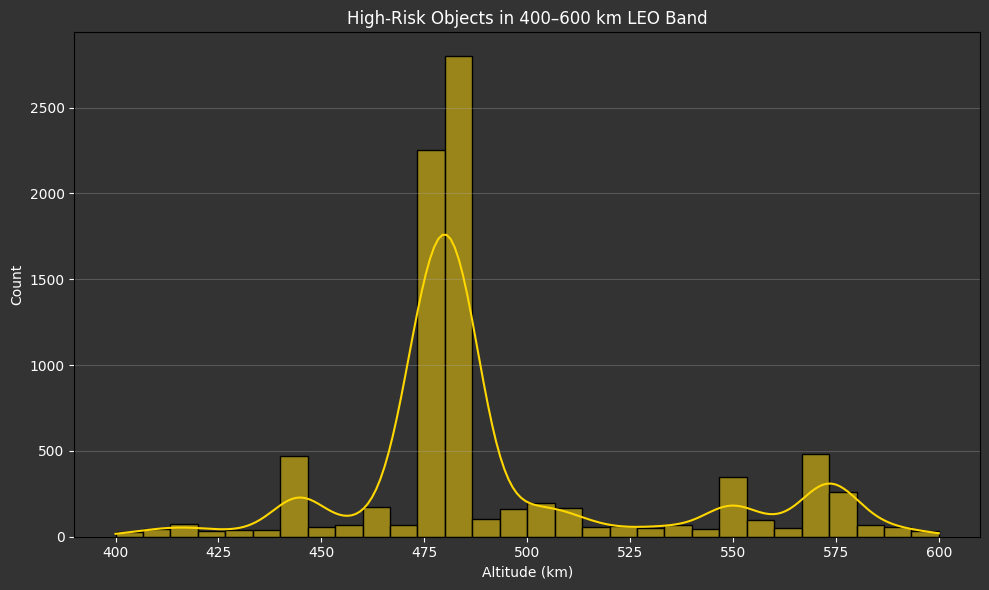

Objects in 400–600 km band: 8449


In [15]:
# Filter for 400–600 km LEO high-risk objects
if 'altitude_km' in df_high_risk.columns:
    leo_band = df_high_risk[(df_high_risk['altitude_km'] >= 400) & (df_high_risk['altitude_km'] <= 600)]
    
    plt.figure(figsize=(10,6))
    sns.histplot(leo_band['altitude_km'], bins=30, kde=True, color='gold')
    
    plt.title('High-Risk Objects in 400–600 km LEO Band')
    plt.xlabel('Altitude (km)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/questions/exploratory/svg/high_risk_banded_exp.svg', bbox_inches='tight')
    plt.savefig('../charts/questions/exploratory/png/high_risk_banded_exp.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f'Objects in 400–600 km band: {len(leo_band)}')
else:
    print('altitude column not found in high-risk data.')